# AIS Trajectory

## Preperations

### Import libraries

In [21]:
from datetime import datetime
from tqdm import tqdm
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

### Load data

In [22]:
filepath_train = 'data/ais_train.csv'
filepath_test = 'data/ais_test.csv'

# Load AIS historical data
train = pd.read_csv(filepath_train, sep ='|')  # Replace with your dataset
test = pd.read_csv(filepath_test, sep = ',')

### Functions

In [23]:
def add_time_features(df):
    df['hour'] = df['time'].dt.hour
    df['day_of_week'] = df['time'].dt.dayofweek
    df['day_of_month'] = df['time'].dt.day
    df['month'] = df['time'].dt.month
    df['time_diff'] = df['time'].diff()
    df['time_diff_seconds'] = df['time_diff'].dt.total_seconds()
    return df

def add_shifted_features(df, n_shifts):
    shifted_dfs = []
    for shift in range(1, n_shifts + 1):
        shifted_df = df.copy()
        shifted_df[f'prev_lat'] = df.groupby('vesselId')['latitude'].shift(shift)
        shifted_df[f'prev_lon'] = df.groupby('vesselId')['longitude'].shift(shift)
        shifted_df[f'prev_speed'] = df.groupby('vesselId')['sog'].shift(shift)
        shifted_df[f'prev_course'] = (df.groupby('vesselId')['cog'].shift(shift) / 180) - 1
        shifted_df[f'prev_rotation'] = df.groupby('vesselId')['rot'].shift(shift)
        shifted_df[f'prev_heading'] = (df.groupby('vesselId')['heading'].shift(shift) / 180) - 1
        shifted_df[f'prev_time_diff_seconds'] = df.groupby('vesselId')['time_diff_seconds'].shift(shift)
        shifted_df[f'prev_hour'] = df.groupby('vesselId')['hour'].shift(shift)
        shifted_df[f'prev_day_of_week'] = df.groupby('vesselId')['day_of_week'].shift(shift)
        shifted_df[f'prev_day_of_month'] = df.groupby('vesselId')['day_of_month'].shift(shift)
        shifted_df[f'prev_month'] = df.groupby('vesselId')['month'].shift(shift)

        shifted_dfs.append(shifted_df)
    
    return pd.concat(shifted_dfs, ignore_index=True)


### Exploraty Data Analysis


Have to transform the values that are not numerical into dummy values, and change the time variable to numerical values. 

In [24]:
# Label encode the vesselId
le = LabelEncoder()
train['vesselId'] = le.fit_transform(train['vesselId'])
test['vesselId'] = le.transform(test['vesselId'])

le_port = LabelEncoder()
train['portId'] = le_port.fit_transform(train['portId'])

# Drop etaRaw column
train = train.drop(columns=['etaRaw'], errors = 'ignore')

# Convert timestamps to numeric
train['time'] = pd.to_datetime(train['time'])
test['time'] = pd.to_datetime(test['time'])

# Convert time to features
train['hour'] = train['time'].dt.hour
train['weekday'] = train['time'].dt.weekday
train['month'] = train['time'].dt.month
train['day'] = train['time'].dt.day

test['hour'] = test['time'].dt.hour
test['weekday'] = test['time'].dt.weekday
test['month'] = test['time'].dt.month
test['day'] = test['time'].dt.day

#Sorting
train.sort_values(by=['vesselId', 'time'], inplace=True)
test.sort_values(by=['vesselId', 'time'], inplace=True)

display(train.head())
display(test.head())

,time,cog,sog,rot,heading,navstat,latitude,longitude,vesselId,portId,hour,weekday,month,day
131115,2024-01-12 14:07:47,308.1,17.1,-6,316,0,7.50361,77.58340,0,112,14,4,1,12
131279,2024-01-12 14:31:00,307.6,17.3,5,313,0,7.57302,77.49505,0,115,14,4,1,12
131514,2024-01-12 14:57:23,306.8,16.9,5,312,0,7.65043,77.39404,0,115,14,4,1,12
131696,2024-01-12 15:18:48,307.9,16.9,6,313,0,7.71275,77.31394,0,115,15,4,1,12
131885,2024-01-12 15:39:47,307.0,16.3,7,313,0,7.77191,77.23585,0,115,15,4,1,12


,ID,vesselId,time,scaling_factor,hour,weekday,month,day
4,4,1,2024-05-08 00:12:27,0.3,0,2,5,8
201,201,1,2024-05-08 00:39:27,0.3,0,2,5,8
583,583,1,2024-05-08 01:33:28,0.3,1,2,5,8
701,701,1,2024-05-08 01:51:26,0.3,1,2,5,8
829,829,1,2024-05-08 02:03:29,0.3,2,2,5,8


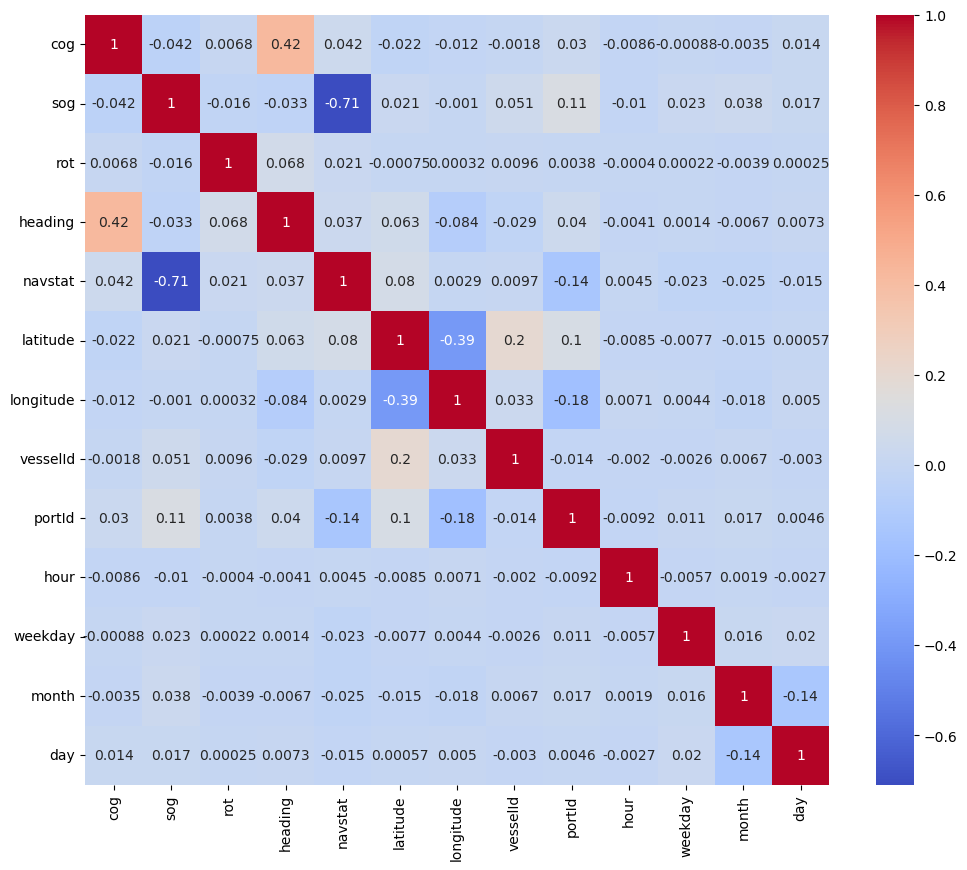

In [25]:
corr = train.drop(columns=['time']).corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

We observe that their is a high correlation between speed over ground and navigal status, heading and course over ground, and longitude and latitude. 

## Preprocessing and feature engineering

### Preprosessing


In [26]:
# Replace special values with NaN
train.replace({'rot': {127: np.nan, -127: np.nan, -128: np.nan},
               'sog': {102.3: np.nan},
               'cog': {360: np.nan},
               'heading': {511: np.nan}}, inplace=True)


#Remove false values
train.loc[train['cog'] > 360, 'cog'] = np.nan
train.loc[(train['latitude'] < -90) | (train['latitude'] > 90), 'latitude'] = np.nan
train.loc[(train['longitude'] < -180) | (train['longitude'] > 180), 'longitude'] = np.nan


train.dropna()


,time,cog,sog,rot,heading,navstat,latitude,longitude,vesselId,portId,hour,weekday,month,day
131115,2024-01-12 14:07:47,308.1,17.1,-6.0,316.0,0,7.50361,77.58340,0,112,14,4,1,12
131279,2024-01-12 14:31:00,307.6,17.3,5.0,313.0,0,7.57302,77.49505,0,115,14,4,1,12
131514,2024-01-12 14:57:23,306.8,16.9,5.0,312.0,0,7.65043,77.39404,0,115,14,4,1,12
131696,2024-01-12 15:18:48,307.9,16.9,6.0,313.0,0,7.71275,77.31394,0,115,15,4,1,12
131885,2024-01-12 15:39:47,307.0,16.3,7.0,313.0,0,7.77191,77.23585,0,115,15,4,1,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521244,2024-05-07 22:36:16,324.1,13.5,-2.0,325.0,0,59.63337,21.43237,687,78,22,1,5,7
1521409,2024-05-07 22:57:05,324.2,13.3,-3.0,326.0,0,59.69588,21.34225,687,78,22,1,5,7
1521625,2024-05-07 23:17:54,356.5,12.2,-1.0,354.0,0,59.76388,21.35317,687,78,23,1,5,7
1521821,2024-05-07 23:38:13,52.6,17.3,3.0,50.0,0,59.83316,21.38489,687,78,23,1,5,7


### Feature engineering

In [27]:
# Feature Engineering
train = add_time_features(train)
train = add_shifted_features(train, 5)

train['3_day_avg_speed'] = train.groupby('vesselId', group_keys=False).apply(
    lambda x: x.sort_values('time').rolling('3D', on='time')['sog'].mean())

# Making is moored
train['isMoored'] = train['navstat'] == 5
train = train[~train['isMoored']]

# Create binary columns for turn direction and magnitude of rotatiobn
train['turn_direction'] = np.where(train['rot'] > 0, 1, 0)
train['turn_magnitude'] = train['rot'].abs()




# Drop rows with missing values
train.dropna(inplace=True)

display(train)

print(f"Length of dataset after preprocessing: {len(train)}")

,time,cog,sog,rot,heading,navstat,latitude,longitude,vesselId,portId,...,prev_heading,prev_time_diff_seconds,prev_hour,prev_day_of_week,prev_day_of_month,prev_month,3_day_avg_speed,isMoored,turn_direction,turn_magnitude
2,2024-01-12 14:57:23,306.8,16.9,5.0,312.0,0,7.65043,77.39404,0,115,...,0.738889,1393.0,14.0,4.0,12.0,1.0,17.114286,False,1,5.0
3,2024-01-12 15:18:48,307.9,16.9,6.0,313.0,0,7.71275,77.31394,0,115,...,0.733333,1583.0,14.0,4.0,12.0,1.0,17.057895,False,1,6.0
4,2024-01-12 15:39:47,307.0,16.3,7.0,313.0,0,7.77191,77.23585,0,115,...,0.738889,1285.0,15.0,4.0,12.0,1.0,16.900000,False,1,7.0
5,2024-01-12 15:54:48,307.6,16.1,5.0,313.0,0,7.81285,77.18147,0,115,...,0.738889,1259.0,15.0,4.0,12.0,1.0,16.789655,False,1,5.0
6,2024-01-12 16:14:59,309.5,16.1,-6.0,313.0,0,7.86929,77.11032,0,115,...,0.738889,901.0,15.0,4.0,12.0,1.0,16.706061,False,0,6.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7610320,2024-05-07 22:36:16,324.1,13.5,-2.0,325.0,0,59.63337,21.43237,687,78,...,0.605556,1278.0,20.0,1.0,7.0,5.0,9.558603,False,0,2.0
7610321,2024-05-07 22:57:05,324.2,13.3,-3.0,326.0,0,59.69588,21.34225,687,78,...,0.616667,1207.0,21.0,1.0,7.0,5.0,9.560870,False,0,3.0
7610322,2024-05-07 23:17:54,356.5,12.2,-1.0,354.0,0,59.76388,21.35317,687,78,...,0.633333,1235.0,21.0,1.0,7.0,5.0,9.528340,False,0,1.0
7610323,2024-05-07 23:38:13,52.6,17.3,3.0,50.0,0,59.83316,21.38489,687,78,...,0.638889,900.0,21.0,1.0,7.0,5.0,9.511610,False,1,3.0


Length of dataset after preprocessing: 4369467


## Model

### Train test split

In [29]:
feats_to_include = ['prev_lat', 'prev_lon', 'prev_speed', 'prev_course', 'prev_rotation', 'prev_heading', 'time_diff_seconds', '3_day_avg_speed']
X = train[feats_to_include]
y = train[['latitude', 'longitude']]

# Split the data into training and validation sets (keeping both latitude and longitude together)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42)

### Train model with parameter optimizing

In [ ]:
best_params = {'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 20}

# Initialize the RandomForestRegressor with the best parameters for latitude
model_lat = RandomForestRegressor(**best_params, random_state=42)
model_lat.fit(X_train, y_train)
print("Models trained with the best parameters from grid search.")

### Make predictions and evaluate the model

In [9]:
# Make predictions on the validation set
y_lat_pred_val = model_lat.predict(X_lat_val)
y_lon_pred_val = model_lon.predict(X_lon_val)

# Evaluate performance on the validation set
mae_lat = mean_absolute_error(y_lat_val, y_lat_pred_val)
mae_lon = mean_absolute_error(y_lon_val, y_lon_pred_val)

print(f'Mean Absolute Error for Latitude: {mae_lat}')
print(f'Mean Absolute Error for Longitude: {mae_lon}')

IndexError: list index out of range

## Predict future vessel coordinates

In [10]:
import concurrent.futures

# Open the test file for reading and the prediction file for writing
f_test = open('data/ais_test.csv', 'r')
f_pred = open('RollingWindow_1.csv', 'w')
f_pred.write("ID,longitude_predicted,latitude_predicted\n")

lines = f_test.readlines()[1:]

def process_line(line):
    id, vesselID, time, scaling_factor = line.split(',')
    
    # Fetch the latest known position of the vessel
    latest_data_points = train[train['vesselId'] == vesselID]
    latest_data_points_sorted = latest_data_points.sort_values(by='time')
    
    # Set 'time' as the index to allow for time-based rolling window
    latest_data_points_sorted = latest_data_points_sorted.set_index('time')
    
    # Apply rolling window on 'sog' with a 3-day window
    latest_data_points_sorted['3_day_avg_speed'] = latest_data_points_sorted['sog'].rolling('3D').mean()
    
    # Get the latest data point
    latest_data_point = latest_data_points_sorted.iloc[-1]

    # Prepare the new data for prediction
    new_data = {
        'prev_lat': latest_data_point['latitude'],
        'prev_lon': latest_data_point['longitude'],
        'prev_speed': latest_data_point['sog'],
        'prev_course': (latest_data_point['cog'] / 180) - 1,
        'prev_rotation': latest_data_point['rot'],
        'prev_heading': (latest_data_point['heading'] / 180) - 1,
        'time_diff_seconds': (pd.to_datetime(time) - latest_data_point.name).total_seconds(),
        '3_day_avg_speed': latest_data_point['3_day_avg_speed'],
        'turn_direction': 1 if latest_data_point['rot'] > 0 else 0,
        'turn_magnitude': latest_data_point['rot'].abs(),
        'hour': pd.to_datetime(time).hour,
        'day_of_week': pd.to_datetime(time).dayofweek,
        'day_of_month': pd.to_datetime(time).day,
        'month': pd.to_datetime(time).month
    }

    # Make predictions
    pred_lat = model_lat.predict([list(new_data.values())])[0]
    pred_lon = model_lon.predict([list(new_data.values())])[0]

    return f"{id},{pred_lon},{pred_lat}\n"

# Use ThreadPoolExecutor to parallelize the processing of lines
with concurrent.futures.ThreadPoolExecutor() as executor:
    results = list(tqdm(executor.map(process_line, lines), total=len(lines)))

# Write predictions to file
f_pred.writelines(results)

f_test.close()
f_pred.close()


  0%|          | 0/51739 [00:00<?, ?it/s]


AttributeError: 'numpy.float64' object has no attribute 'abs'